In [96]:
#IMPORTAÇÕES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#CARREGAMENTO DE BASE TRATADA

df = pd.read_csv('superstore_tratado_pt.csv')
df.head()

,ID Linha,ID Pedido,Data Pedido,Data Envio,Modalidade Envio,ID Cliente,Nome Cliente,Segmento,Pais,Cidade,...,CEP,Regiao,ID Produto,Categoria,Subcategoria,Produto,Receita,Quantidade,Desconto,Lucro
0,1,CA-2016-152156,11/8/2016,11/11/2016,Segunda Classe,CG-12520,Claire Gute,Consumidor,United States,Henderson,...,42420,Sul,FUR-BO-10001798,Moveis,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Segunda Classe,CG-12520,Claire Gute,Consumidor,United States,Henderson,...,42420,Sul,FUR-CH-10000454,Moveis,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Segunda Classe,DV-13045,Darrin Van Huff,Corporativo,United States,Los Angeles,...,90036,Oeste,OFF-LA-10000240,Materiais Escritorio,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Classe Padrao,SO-20335,Sean O'Donnell,Consumidor,United States,Fort Lauderdale,...,33311,Sul,FUR-TA-10000577,Moveis,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Classe Padrao,SO-20335,Sean O'Donnell,Consumidor,United States,Fort Lauderdale,...,33311,Sul,OFF-ST-10000760,Materiais Escritorio,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [97]:
# CARACTERIZAÇÃO DO DATASET

print(df.shape)

df.dtypes

df.isnull().sum()

df.describe()

df.info()

(9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID Linha          9994 non-null   int64  
 1   ID Pedido         9994 non-null   object 
 2   Data Pedido       9994 non-null   object 
 3   Data Envio        9994 non-null   object 
 4   Modalidade Envio  9994 non-null   object 
 5   ID Cliente        9994 non-null   object 
 6   Nome Cliente      9994 non-null   object 
 7   Segmento          9994 non-null   object 
 8   Pais              9994 non-null   object 
 9   Cidade            9994 non-null   object 
 10  Estado            9994 non-null   object 
 11  CEP               9994 non-null   int64  
 12  Regiao            9994 non-null   object 
 13  ID Produto        9994 non-null   object 
 14  Categoria         9994 non-null   object 
 15  Subcategoria      9994 non-null   object 
 16  Produto           9994 non-null

In [98]:
# AJUSTES TEMPORAIS

df['Data Pedido'] = pd.to_datetime(df['Data Pedido'])
df['Data Envio'] = pd.to_datetime(df['Data Envio'])

df[['Data Pedido','Data Envio']].dtypes

Data Pedido    datetime64[ns]
Data Envio     datetime64[ns]
dtype: object

In [100]:
# CONFIGURAÇÃO VISUAL ESCOLHIDA

cor_principal = '#292C7A'
cor_secundaria = '#E6E6E6'
cor_fundo = '#FFFFFF'

sns.set_style("whitegrid")

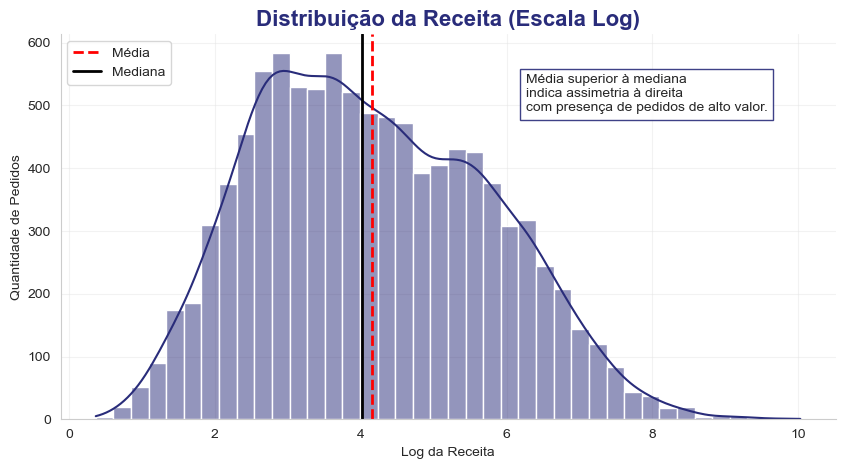

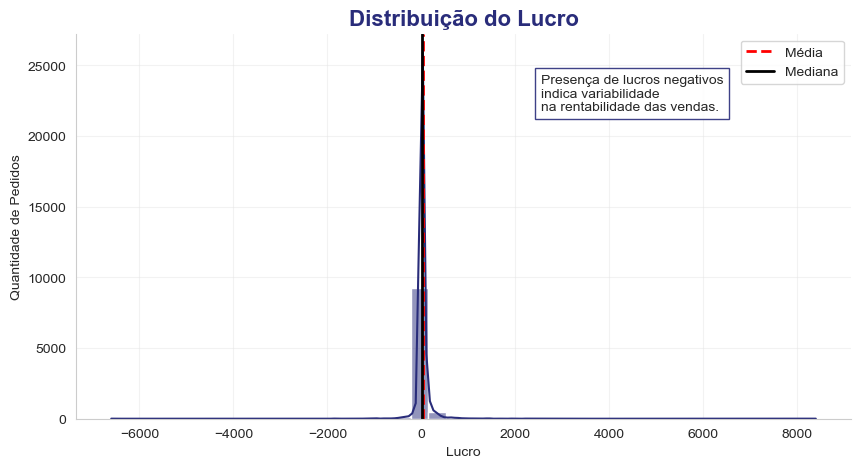

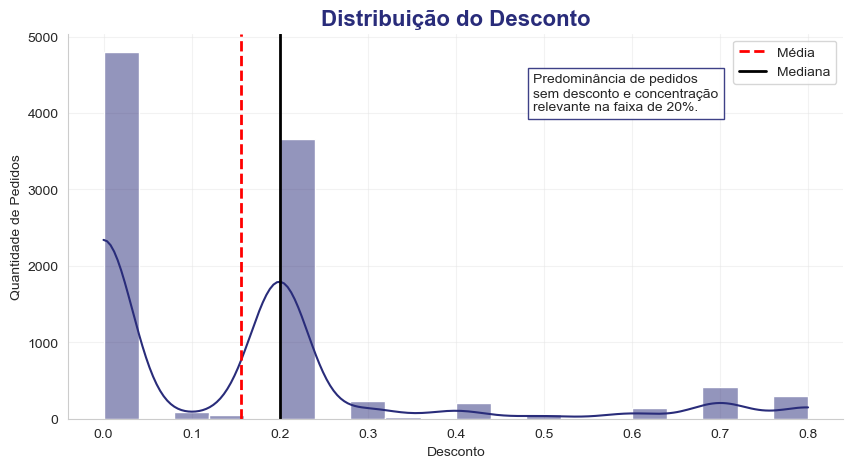

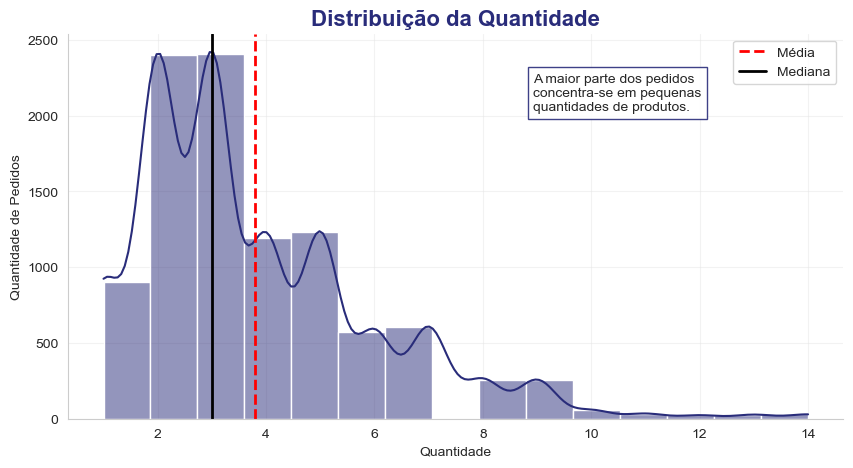

In [101]:
# DISTRIBUIÇÕES ESTATÍSTICAS

#===================================================
# RECEITA
#===================================================

plt.figure(figsize=(10,5))
plt.gcf().set_facecolor(cor_fundo)

receita_log = np.log1p(df['Receita'])

media = receita_log.mean()
mediana = receita_log.median()

sns.histplot(
    receita_log,
    bins=40,
    kde=True,
    color=cor_principal
)

plt.axvline(media, color='red', linestyle='--', linewidth=2, label='Média')
plt.axvline(mediana, color='black', linewidth=2, label='Mediana')

plt.text(
    0.60, 0.80,
    'Média superior à mediana\nindica assimetria à direita\ncom presença de pedidos de alto valor.',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor=cor_principal, alpha=0.9)
)

plt.title(
    'Distribuição da Receita (Escala Log)',
    fontsize=16,
    fontweight='bold',
    color=cor_principal
)

plt.xlabel('Log da Receita')
plt.ylabel('Quantidade de Pedidos')
plt.grid(color=cor_secundaria, alpha=0.5)
plt.legend()
sns.despine()
plt.show()


#===================================================
# LUCRO
#===================================================

plt.figure(figsize=(10,5))
plt.gcf().set_facecolor(cor_fundo)

media = df['Lucro'].mean()
mediana = df['Lucro'].median()

sns.histplot(
    df['Lucro'],
    bins=40,
    kde=True,
    color=cor_principal
)

plt.axvline(media, color='red', linestyle='--', linewidth=2, label='Média')
plt.axvline(mediana, color='black', linewidth=2, label='Mediana')

plt.text(
    0.60, 0.80,
    'Presença de lucros negativos\nindica variabilidade\nna rentabilidade das vendas.',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor=cor_principal, alpha=0.9)
)

plt.title(
    'Distribuição do Lucro',
    fontsize=16,
    fontweight='bold',
    color=cor_principal
)

plt.xlabel('Lucro')
plt.ylabel('Quantidade de Pedidos')
plt.grid(color=cor_secundaria, alpha=0.5)
plt.legend()
sns.despine()
plt.show()


#===================================================
# DESCONTO
#===================================================

plt.figure(figsize=(10,5))
plt.gcf().set_facecolor(cor_fundo)

media = df['Desconto'].mean()
mediana = df['Desconto'].median()

sns.histplot(
    df['Desconto'],
    bins=20,
    kde=True,
    color=cor_principal
)

plt.axvline(media, color='red', linestyle='--', linewidth=2, label='Média')
plt.axvline(mediana, color='black', linewidth=2, label='Mediana')

plt.text(
    0.60, 0.80,
    'Predominância de pedidos\nsem desconto e concentração\nrelevante na faixa de 20%.',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor=cor_principal, alpha=0.9)
)

plt.title(
    'Distribuição do Desconto',
    fontsize=16,
    fontweight='bold',
    color=cor_principal
)

plt.xlabel('Desconto')
plt.ylabel('Quantidade de Pedidos')
plt.grid(color=cor_secundaria, alpha=0.5)
plt.legend()
sns.despine()
plt.show()


#===================================================
# QUANTIDADE
#===================================================

plt.figure(figsize=(10,5))
plt.gcf().set_facecolor(cor_fundo)

media = df['Quantidade'].mean()
mediana = df['Quantidade'].median()

sns.histplot(
    df['Quantidade'],
    bins=15,
    kde=True,
    color=cor_principal
)

plt.axvline(media, color='red', linestyle='--', linewidth=2, label='Média')
plt.axvline(mediana, color='black', linewidth=2, label='Mediana')

plt.text(
    0.60, 0.80,
    'A maior parte dos pedidos\nconcentra-se em pequenas\nquantidades de produtos.',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor=cor_principal, alpha=0.9)
)

plt.title(
    'Distribuição da Quantidade',
    fontsize=16,
    fontweight='bold',
    color=cor_principal
)

plt.xlabel('Quantidade')
plt.ylabel('Quantidade de Pedidos')
plt.grid(color=cor_secundaria, alpha=0.5)
plt.legend()
sns.despine()
plt.show()

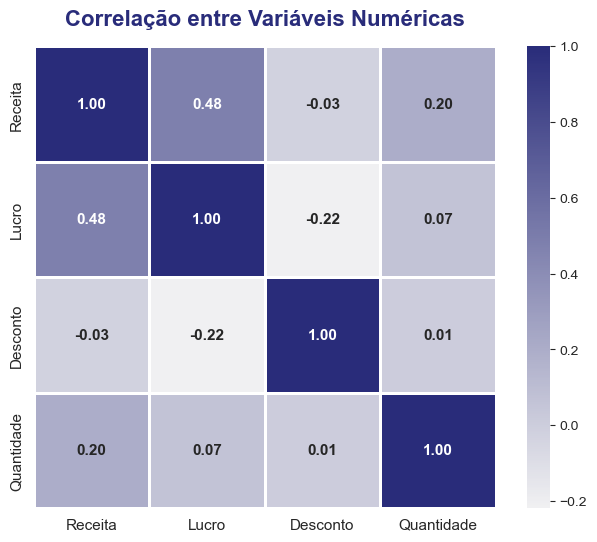

In [102]:
#===================================================
# HEATMAP DE CORRELAÇÃO
#===================================================

corr = df[['Receita','Lucro','Desconto','Quantidade']].corr()

plt.figure(figsize=(8,6))
plt.gcf().set_facecolor(cor_fundo)

sns.heatmap(
    corr,
    annot=True,
    cmap=sns.light_palette(
        cor_principal,
        as_cmap=True
    ),
    fmt='.2f',
    linewidths=1,
    linecolor='white',
    square=True,
    cbar=True,
    annot_kws={
        'fontsize':11,
        'fontweight':'bold'
    }
)

plt.title(
    'Correlação entre Variáveis Numéricas',
    fontsize=16,
    fontweight='bold',
    color=cor_principal,
    pad=15
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()

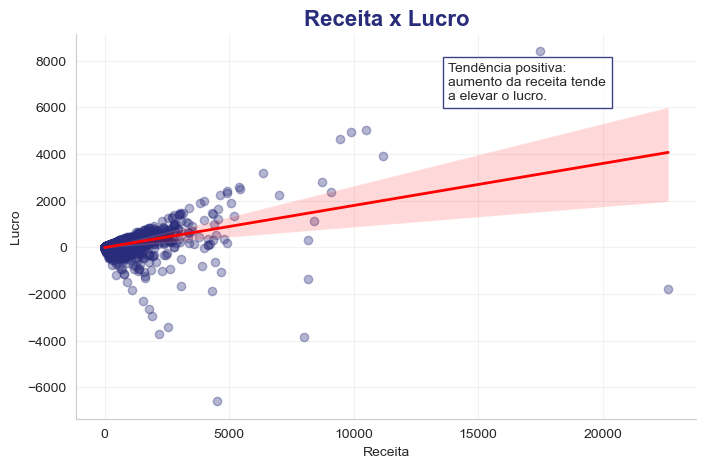

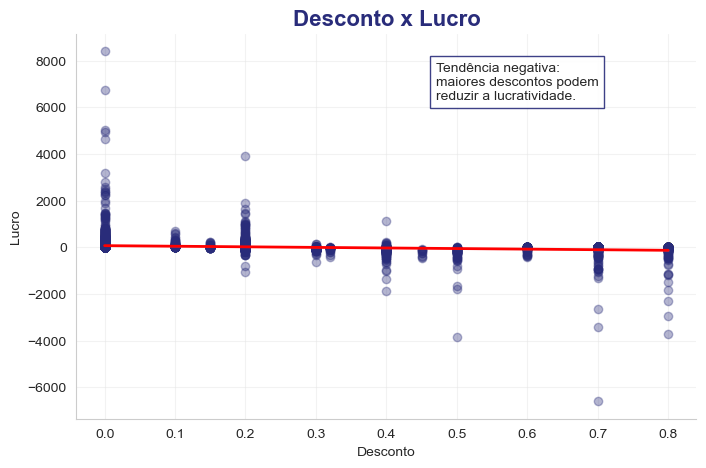

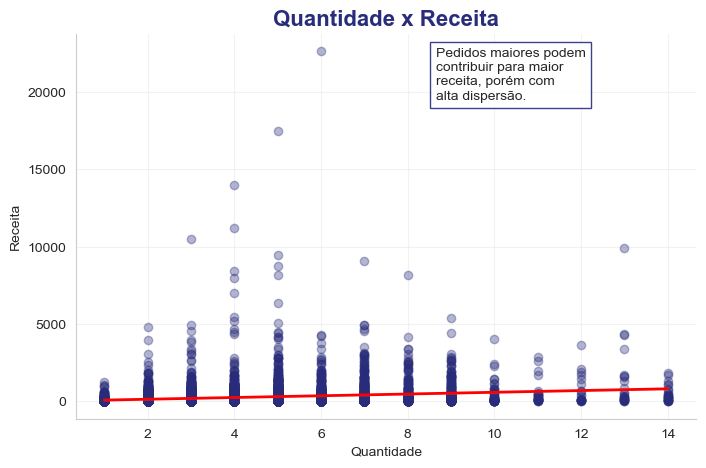

In [103]:
#RELAÇÕES ENTRE VARIÁVEIS

#===================================================
# RECEITA X LUCRO
#===================================================

plt.figure(figsize=(8,5))
plt.gcf().set_facecolor(cor_fundo)

sns.regplot(
    data=df,
    x='Receita',
    y='Lucro',
    scatter_kws={
        'alpha':0.35,
        'color':cor_principal
    },
    line_kws={
        'color':'red',
        'linewidth':2
    }
)

plt.title(
    'Receita x Lucro',
    fontsize=16,
    fontweight='bold',
    color=cor_principal
)

plt.xlabel('Receita')
plt.ylabel('Lucro')

plt.grid(color=cor_secundaria, alpha=0.5)

plt.text(
    0.60,0.83,
    'Tendência positiva:\naumento da receita tende\na elevar o lucro.',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(
        facecolor='white',
        edgecolor=cor_principal,
        alpha=0.9
    )
)

sns.despine()
plt.show()

#===================================================
# DESCONTO X LUCRO
#===================================================

plt.figure(figsize=(8,5))
plt.gcf().set_facecolor(cor_fundo)

sns.regplot(
    data=df,
    x='Desconto',
    y='Lucro',
    scatter_kws={
        'alpha':0.35,
        'color':cor_principal
    },
    line_kws={
        'color':'red',
        'linewidth':2
    }
)

plt.title(
    'Desconto x Lucro',
    fontsize=16,
    fontweight='bold',
    color=cor_principal
)

plt.xlabel('Desconto')
plt.ylabel('Lucro')

plt.grid(color=cor_secundaria, alpha=0.5)

plt.text(
    0.58,0.83,
    'Tendência negativa:\nmaiores descontos podem\nreduzir a lucratividade.',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(
        facecolor='white',
        edgecolor=cor_principal,
        alpha=0.9
    )
)

sns.despine()
plt.show()

#===================================================
# QUANTIDADE X RECEITA
#===================================================

plt.figure(figsize=(8,5))
plt.gcf().set_facecolor(cor_fundo)

sns.regplot(
    data=df,
    x='Quantidade',
    y='Receita',
    scatter_kws={
        'alpha':0.35,
        'color':cor_principal
    },
    line_kws={
        'color':'red',
        'linewidth':2
    }
)

plt.title(
    'Quantidade x Receita',
    fontsize=16,
    fontweight='bold',
    color=cor_principal
)

plt.xlabel('Quantidade')
plt.ylabel('Receita')

plt.grid(color=cor_secundaria, alpha=0.5)

plt.text(
    0.58,0.83,
    'Pedidos maiores podem\ncontribuir para maior\nreceita, porém com\nalta dispersão.',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(
        facecolor='white',
        edgecolor=cor_principal,
        alpha=0.9
    )
)

sns.despine()
plt.show()


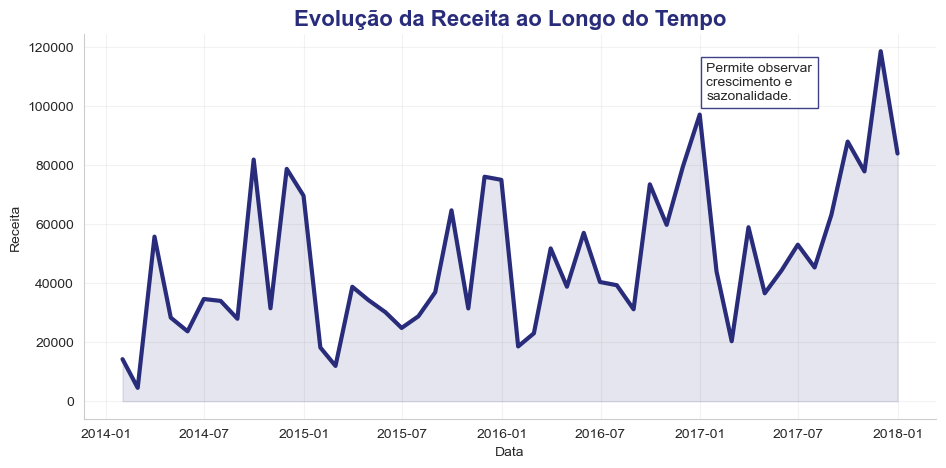

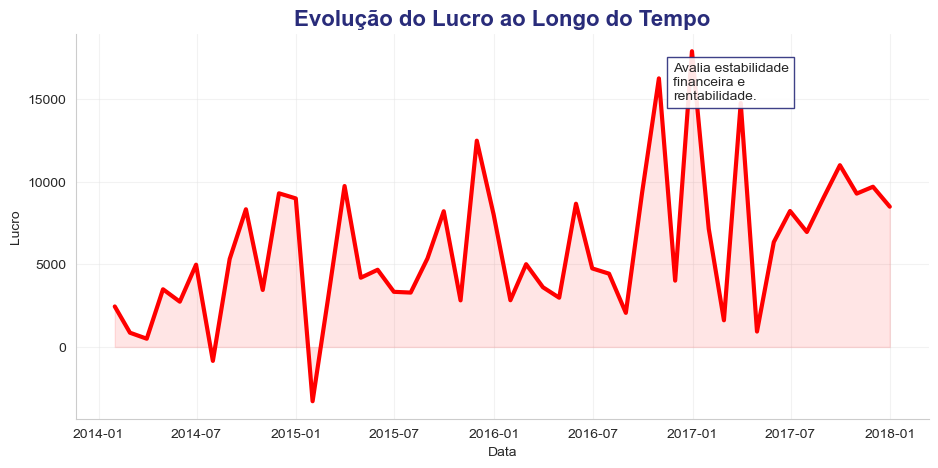

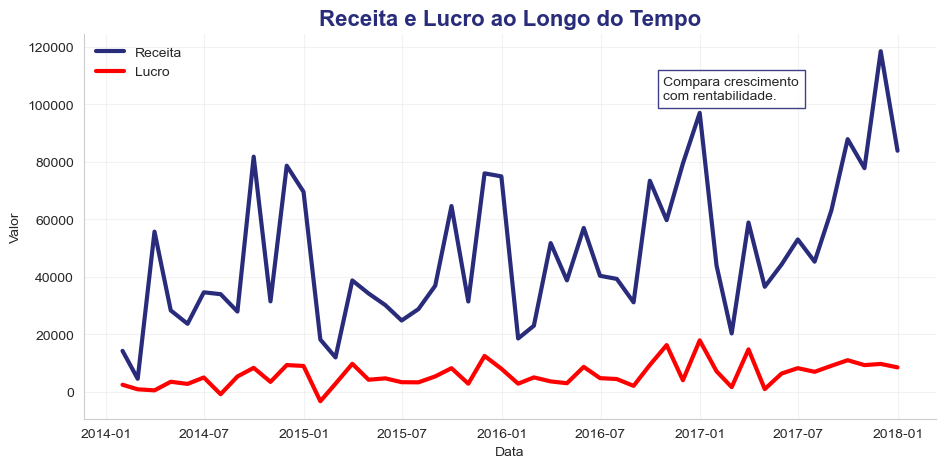

In [104]:
# ANÁLISE TEMPORAL E SAZONALIDADE

#===================================================
# RECEITA AO LONGO DO TEMPO
#===================================================

receita_mensal = (
    df.groupby('Data Pedido')['Receita']
    .sum()
    .resample('ME')
    .sum()
)

plt.figure(figsize=(11,5))
plt.gcf().set_facecolor(cor_fundo)

plt.plot(
    receita_mensal.index,
    receita_mensal.values,
    color=cor_principal,
    linewidth=3
)

plt.fill_between(
    receita_mensal.index,
    receita_mensal.values,
    color=cor_principal,
    alpha=0.12
)

plt.title(
    'Evolução da Receita ao Longo do Tempo',
    fontsize=16,
    fontweight='bold',
    color=cor_principal
)

plt.xlabel('Data')
plt.ylabel('Receita')

plt.grid(
    color=cor_secundaria,
    alpha=0.5
)

plt.text(
    0.73,0.83,
    'Permite observar\ncrescimento e\nsazonalidade.',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(
        facecolor='white',
        edgecolor=cor_principal,
        alpha=0.9
    )
)

sns.despine()
plt.show()

#===================================================
# LUCRO AO LONGO DO TEMPO
#===================================================

lucro_mensal = (
    df.groupby('Data Pedido')['Lucro']
    .sum()
    .resample('ME')
    .sum()
)

plt.figure(figsize=(11,5))
plt.gcf().set_facecolor(cor_fundo)

plt.plot(
    lucro_mensal.index,
    lucro_mensal.values,
    color='red',
    linewidth=3
)

plt.fill_between(
    lucro_mensal.index,
    lucro_mensal.values,
    color='red',
    alpha=0.10
)

plt.title(
    'Evolução do Lucro ao Longo do Tempo',
    fontsize=16,
    fontweight='bold',
    color=cor_principal
)

plt.xlabel('Data')
plt.ylabel('Lucro')

plt.grid(
    color=cor_secundaria,
    alpha=0.5
)

plt.text(
    0.70,0.83,
    'Avalia estabilidade\nfinanceira e\nrentabilidade.',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(
        facecolor='white',
        edgecolor=cor_principal,
        alpha=0.9
    )
)

sns.despine()
plt.show()

#===================================================
# RECEITA X LUCRO NO TEMPO
#===================================================

mensal = (
    df.groupby('Data Pedido')
    [['Receita','Lucro']]
    .sum()
    .resample('ME')
    .sum()
)

plt.figure(figsize=(11,5))
plt.gcf().set_facecolor(cor_fundo)

plt.plot(
    mensal.index,
    mensal['Receita'],
    color=cor_principal,
    linewidth=3,
    label='Receita'
)

plt.plot(
    mensal.index,
    mensal['Lucro'],
    color='red',
    linewidth=3,
    label='Lucro'
)

plt.title(
    'Receita e Lucro ao Longo do Tempo',
    fontsize=16,
    fontweight='bold',
    color=cor_principal
)

plt.xlabel('Data')
plt.ylabel('Valor')

plt.grid(
    color=cor_secundaria,
    alpha=0.5
)

plt.legend(
    frameon=False
)

plt.text(
    0.68,0.83,
    'Compara crescimento\ncom rentabilidade.',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(
        facecolor='white',
        edgecolor=cor_principal,
        alpha=0.9
    )
)

sns.despine()
plt.show()

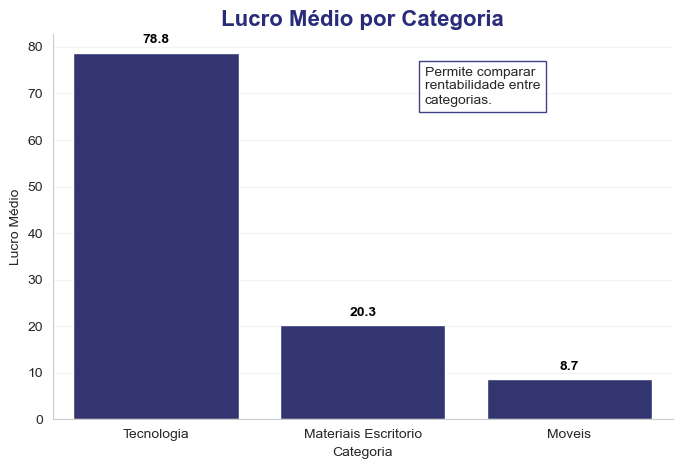

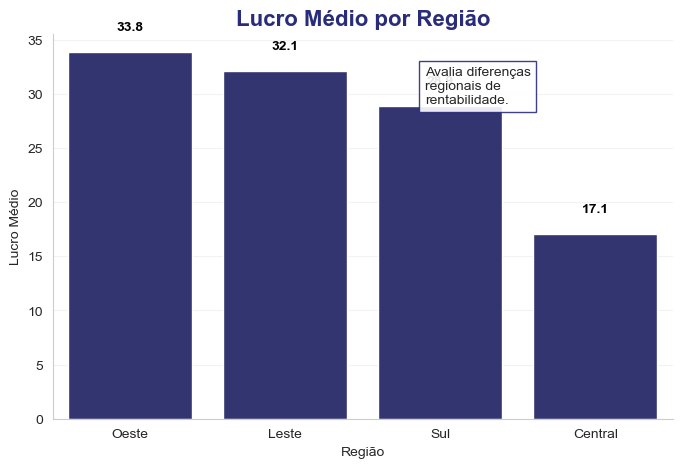

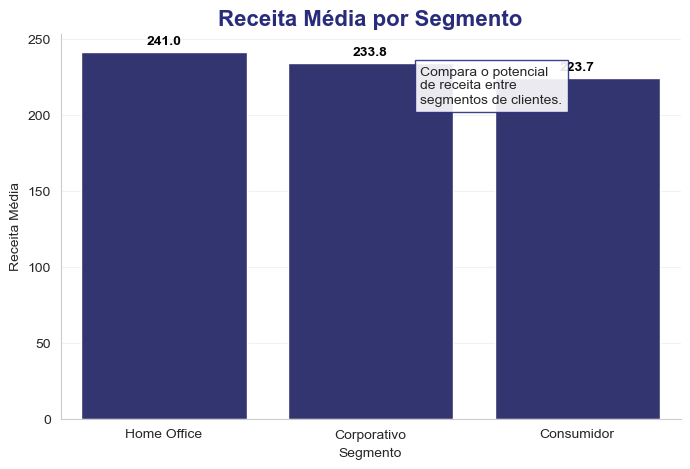

In [139]:
# ANÁLISE CATEGÓRICA

#===================================================
# CATEGORIA X LUCRO
#===================================================

plt.figure(figsize=(8,5))
plt.gcf().set_facecolor(cor_fundo)

categoria_lucro = (
    df.groupby('Categoria')['Lucro']
    .mean()
    .sort_values(ascending=False)
)

ax = sns.barplot(
    x=categoria_lucro.index,
    y=categoria_lucro.values,
    color=cor_principal
)

plt.title(
    'Lucro Médio por Categoria',
    fontsize=16,
    fontweight='bold',
    color=cor_principal
)

plt.xlabel('Categoria')
plt.ylabel('Lucro Médio')

plt.grid(
    axis='y',
    color=cor_secundaria,
    alpha=0.5
)

# VALORES NAS BARRAS
for i, v in enumerate(categoria_lucro.values):
    ax.text(
        i,
        v + 2,
        f'{v:.1f}',
        ha='center',
        color='black',
        fontsize=10,
        fontweight='bold'
    )

plt.text(
    0.60,0.82,
    'Permite comparar\nrentabilidade entre\ncategorias.',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(
        facecolor='white',
        edgecolor=cor_principal,
        alpha=0.9
    )
)

sns.despine()
plt.show()

#===================================================
# REGIAO X LUCRO
#===================================================

plt.figure(figsize=(8,5))
plt.gcf().set_facecolor(cor_fundo)

regiao_lucro = (
    df.groupby('Regiao')['Lucro']
    .mean()
    .sort_values(ascending=False)
)

ax = sns.barplot(
    x=regiao_lucro.index,
    y=regiao_lucro.values,
    color=cor_principal
)

plt.title(
    'Lucro Médio por Região',
    fontsize=16,
    fontweight='bold',
    color=cor_principal
)

plt.xlabel('Região')
plt.ylabel('Lucro Médio')

plt.grid(
    axis='y',
    color=cor_secundaria,
    alpha=0.5
)

# VALORES NAS BARRAS
for i, v in enumerate(regiao_lucro.values):
    ax.text(
        i,
        v + 2,
        f'{v:.1f}',
        ha='center',
        color='black',
        fontsize=10,
        fontweight='bold'
    )

plt.text(
    0.60,0.82,
    'Avalia diferenças\nregionais de\nrentabilidade.',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(
        facecolor='white',
        edgecolor=cor_principal,
        alpha=0.9
    )
)

sns.despine()
plt.show()

#===================================================
# SEGMENTO X RECEITA
#===================================================

plt.figure(figsize=(8,5))
plt.gcf().set_facecolor(cor_fundo)

segmento_receita = (
    df.groupby('Segmento')['Receita']
    .mean()
    .sort_values(ascending=False)
)

ax = sns.barplot(
    x=segmento_receita.index,
    y=segmento_receita.values,
    color=cor_principal
)

plt.title(
    'Receita Média por Segmento',
    fontsize=16,
    fontweight='bold',
    color=cor_principal
)

plt.xlabel('Segmento')
plt.ylabel('Receita Média')

plt.grid(
    axis='y',
    color=cor_secundaria,
    alpha=0.5
)

# VALORES NAS BARRAS
for i, v in enumerate(segmento_receita.values):
    ax.text(
        i,
        v + 5,
        f'{v:.1f}',
        ha='center',
        color='black',
        fontsize=10,
        fontweight='bold'
    )

plt.text(
    0.58,0.82,
    'Compara o potencial\nde receita entre\nsegmentos de clientes.',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(
        facecolor='white',
        edgecolor=cor_principal,
        alpha=0.9
    )
)

sns.despine()
plt.show()

In [105]:
# FEATURE ENGINEERING

#===================================================
# MARGEM DE LUCRO
#===================================================

df['Margem_%'] = (
    df['Lucro'] / df['Receita']
) * 100

df[['Receita','Lucro','Margem_%']].head()


#===================================================
# LUCRO POSITIVO / NEGATIVO
#===================================================

df['Status_Lucro'] = np.where(
    df['Lucro'] >= 0,
    'Positivo',
    'Negativo'
)

df['Status_Lucro'].value_counts()


#===================================================
# VALIDACAO FEATURES
#===================================================

df[
    [
        'Receita',
        'Lucro',
        'Margem_%',
        'Status_Lucro'
    ]
].head()

#===================================================
# FAIXA DE DESCONTO
#===================================================

def faixa_desconto(x):
    
    if x == 0:
        return 'Sem Desconto'
    elif x <= 0.10:
        return 'Baixo'
    elif x <= 0.20:
        return 'Medio'
    else:
        return 'Alto'

df['Faixa_Desconto'] = df['Desconto'].apply(
    faixa_desconto
)

df['Faixa_Desconto'].value_counts()

Faixa_Desconto
Sem Desconto    4798
Medio           3709
Alto            1393
Baixo             94
Name: count, dtype: int64

In [107]:
# MODELAGEM PREDITIVA

#===================================================
# PREPARAÇÃO PARA MODELAGEM
#===================================================

from sklearn.model_selection import train_test_split

features = [
    'Receita',
    'Desconto',
    'Quantidade',
    'Categoria',
    'Segmento',
    'Regiao',
    'Faixa_Desconto'
]

target = 'Lucro'

# encoding categóricas

df_modelo = pd.get_dummies(
    df[features],
    drop_first=True,
    dtype=int
)

X = df_modelo
y = df[target]

print(X.shape)
print(y.shape)

X.head()

(9994, 13)
(9994,)


,Receita,Desconto,Quantidade,Categoria_Moveis,Categoria_Tecnologia,Segmento_Corporativo,Segmento_Home Office,Regiao_Leste,Regiao_Oeste,Regiao_Sul,Faixa_Desconto_Baixo,Faixa_Desconto_Medio,Faixa_Desconto_Sem Desconto
0,261.9600,0.00,2,1,0,0,0,0,0,1,0,0,1
1,731.9400,0.00,3,1,0,0,0,0,0,1,0,0,1
2,14.6200,0.00,2,0,0,1,0,0,1,0,0,0,1
3,957.5775,0.45,5,1,0,0,0,0,0,1,0,0,0
4,22.3680,0.20,2,0,0,0,0,0,0,1,0,1,0


In [108]:
#===================================================
# DIVISÃO TREINO / TESTE
#===================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print('Treino X:', X_train.shape)
print('Teste X:', X_test.shape)
print('Treino y:', y_train.shape)
print('Teste y:', y_test.shape)

Treino X: (7995, 13)
Teste X: (1999, 13)
Treino y: (7995,)
Teste y: (1999,)


In [109]:
#===================================================
# MODELO 1 — REGRESSÃO LINEAR
#===================================================

from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()

modelo_lr.fit(
    X_train,
    y_train
)

pred_lr = modelo_lr.predict(
    X_test
)

print(pred_lr[:10])

[ 126.30993371   -8.38466528   11.80763023 -137.58041875  -18.10240374
   14.59314566  -76.24111013   45.42762519 -111.77442902  -60.82796034]


In [110]:
#===================================================
# AVALIAÇÃO — REGRESSÃO LINEAR
#===================================================

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

r2_lr = r2_score(
    y_test,
    pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        pred_lr
    )
)

mae_lr = mean_absolute_error(
    y_test,
    pred_lr
)

print('R²:', round(r2_lr,3))
print('RMSE:', round(rmse_lr,2))
print('MAE:', round(mae_lr,2))

R²: -0.723
RMSE: 289.0
MAE: 66.27


In [114]:
#===================================================
# MODELO 2 — RANDOM FOREST
#===================================================

from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

modelo_rf.fit(
    X_train,
    y_train
)

pred_rf = modelo_rf.predict(
    X_test
)

print(pred_rf[:10])

[ 21.954875     9.1068525   12.649857   -43.4838835   -6.58646055
  18.6154985  -72.2079515    8.102202   -15.76357417  21.1942685 ]


In [116]:
#===================================================
# AVALIAÇÃO — RANDOM FOREST
#===================================================

r2_rf = r2_score(
    y_test,
    pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        pred_rf
    )
)

mae_rf = mean_absolute_error(
    y_test,
    pred_rf
)

print('R²:', round(r2_rf,3))
print('RMSE:', round(rmse_rf,2))
print('MAE:', round(mae_rf,2))

R²: -0.064
RMSE: 227.08
MAE: 31.86


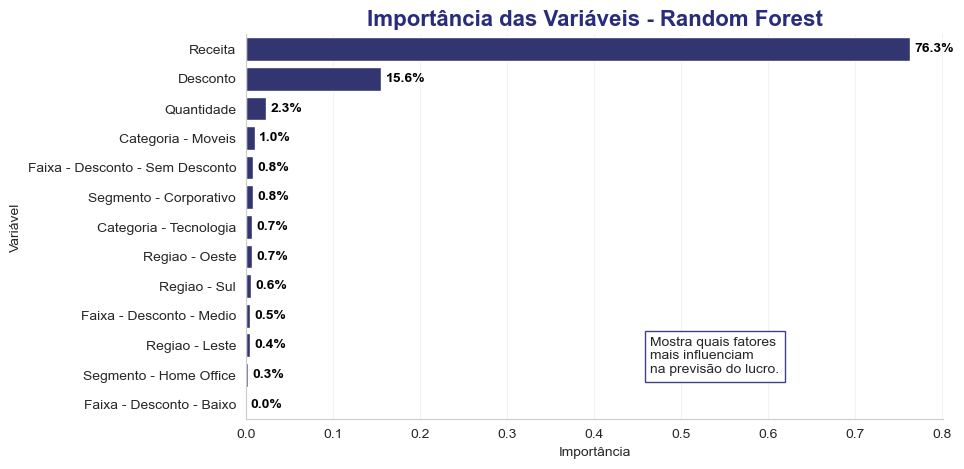

,Variavel,Importancia
0,Receita,0.762921
1,Desconto,0.155527
2,Quantidade,0.023369
3,Categoria - Moveis,0.009901
12,Faixa - Desconto - Sem Desconto,0.008355
5,Segmento - Corporativo,0.008102
4,Categoria - Tecnologia,0.007408
8,Regiao - Oeste,0.006612
9,Regiao - Sul,0.005529
11,Faixa - Desconto - Medio,0.004957


In [123]:
#===================================================
# IMPORTÂNCIA DAS VARIÁVEIS
#===================================================

importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': modelo_rf.feature_importances_
})

importancias = (
    importancias
    .sort_values(
        'Importancia',
        ascending=False
    )
)

# AJUSTE NOMES VISUAIS
importancias['Variavel'] = (
    importancias['Variavel']
    .str.replace('_', ' - ')
)

plt.figure(figsize=(9,5))
plt.gcf().set_facecolor(cor_fundo)

ax = sns.barplot(
    data=importancias,
    x='Importancia',
    y='Variavel',
    color=cor_principal
)

plt.title(
    'Importância das Variáveis - Random Forest',
    fontsize=16,
    fontweight='bold',
    color=cor_principal
)

plt.xlabel('Importância')
plt.ylabel('Variável')

plt.grid(
    axis='x',
    color=cor_secundaria,
    alpha=0.5
)

# VALORES NAS BARRAS
for i, v in enumerate(importancias['Importancia']):
    ax.text(
        v + 0.005,
        i,
        f'{v*100:.1f}%',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

# CARTÃO EXPLICATIVO
plt.text(
    0.58,0.12,
    'Mostra quais fatores\nmais influenciam\nna previsão do lucro.',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(
        facecolor='white',
        edgecolor=cor_principal,
        alpha=0.9
    )
)

sns.despine()
plt.show()

importancias.head(10)

In [125]:
#===================================================
# OVERFITTING E COMPARAÇÃO DOS MODELOS
#===================================================

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

#---------------------------------------------------
# RANDOM FOREST - TREINO
#---------------------------------------------------

pred_train_rf = modelo_rf.predict(X_train)

r2_train = r2_score(
    y_train,
    pred_train_rf
)

r2_test = r2_score(
    y_test,
    pred_rf
)

#---------------------------------------------------
# TABELA COMPARAÇÃO
#---------------------------------------------------

comparacao = pd.DataFrame({
    'Modelo': [
        'Regressão Linear',
        'Random Forest'
    ],
    'R²': [
        r2_lr,
        r2_rf
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf
    ],
    'MAE': [
        mae_lr,
        mae_rf
    ]
})

comparacao

,Modelo,R²,RMSE,MAE
0,Regressão Linear,-0.722593,288.998551,66.266291
1,Random Forest,-0.063539,227.081058,31.857096


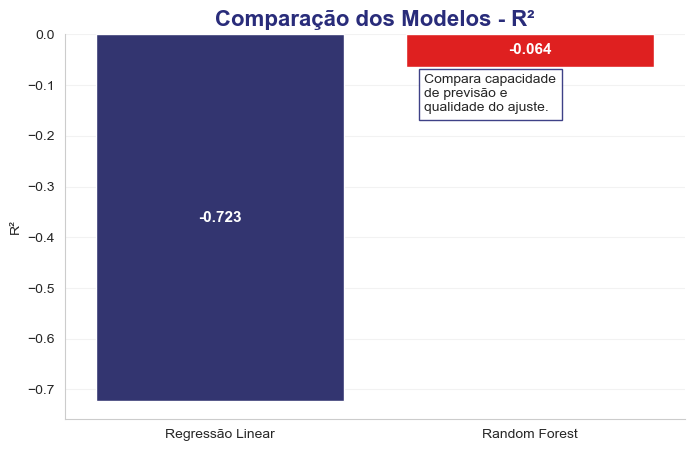

In [133]:
#===================================================
# COMPARAÇÃO VISUAL
#===================================================

plt.figure(figsize=(8,5))
plt.gcf().set_facecolor(cor_fundo)

ax = sns.barplot(
    data=comparacao,
    x='Modelo',
    y='R²',
    hue='Modelo',
    palette=[
        cor_principal,
        'red'
    ],
    legend=False
)

plt.title(
    'Comparação dos Modelos - R²',
    fontsize=16,
    fontweight='bold',
    color=cor_principal
)

plt.xlabel('')
plt.ylabel('R²')

plt.grid(
    axis='y',
    color=cor_secundaria,
    alpha=0.5
)

# VALORES NAS COLUNAS
for i, v in enumerate(comparacao['R²']):
    ax.text(
        i,
        v/2,
        f'{v:.3f}',
        ha='center',
        va='center',
        color='white',
        fontsize=11,
        fontweight='bold'
    )
    
plt.text(
    0.58,0.80,
    'Compara capacidade\nde previsão e\nqualidade do ajuste.',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(
        facecolor='white',
        edgecolor=cor_principal,
        alpha=0.9
    )
)

sns.despine()
plt.show()

In [134]:
print('R² Treino RF:', round(r2_train,3))
print('R² Teste RF:', round(r2_test,3))

R² Treino RF: 0.965
R² Teste RF: -0.064


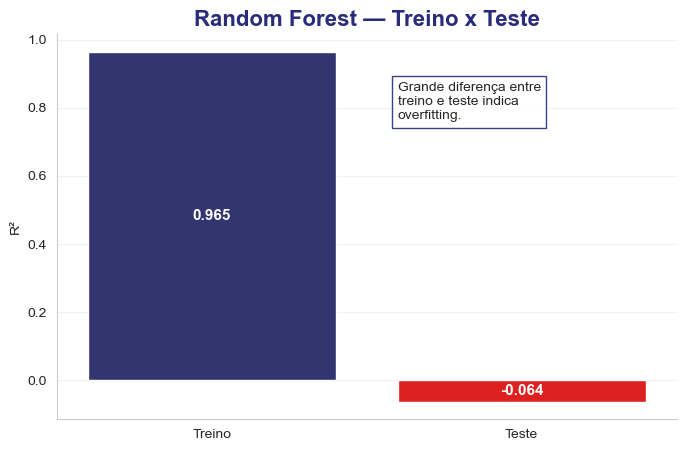

In [135]:
#===================================================
# RANDOM FOREST — TREINO X TESTE
#===================================================

comparacao_rf = pd.DataFrame({
    'Base': [
        'Treino',
        'Teste'
    ],
    'R²': [
        r2_train,
        r2_test
    ]
})

plt.figure(figsize=(8,5))
plt.gcf().set_facecolor(cor_fundo)

ax = sns.barplot(
    data=comparacao_rf,
    x='Base',
    y='R²',
    hue='Base',
    palette=[
        cor_principal,
        'red'
    ],
    legend=False
)

plt.title(
    'Random Forest — Treino x Teste',
    fontsize=16,
    fontweight='bold',
    color=cor_principal
)

plt.xlabel('')
plt.ylabel('R²')

plt.grid(
    axis='y',
    color=cor_secundaria,
    alpha=0.5
)

# VALORES NAS BARRAS
for i, v in enumerate(comparacao_rf['R²']):
    ax.text(
        i,
        v/2,
        f'{v:.3f}',
        ha='center',
        va='center',
        color='white',
        fontsize=11,
        fontweight='bold'
    )

plt.text(
    0.55,0.78,
    'Grande diferença entre\ntreino e teste indica\noverfitting.',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(
        facecolor='white',
        edgecolor=cor_principal,
        alpha=0.9
    )
)

sns.despine()
plt.show()